# Exp:1

In [20]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,Dense,Flatten
corpus=[
    "I like deep learning",
    "Deep learning models can learn word embeddings",
    "Word embeddings capture semantic meaning of words",
    "Neural networks are powerful for NLP tasks"
]
tokenizer=Tokenizer()
tokenizer.fit_on_texts(corpus)
word_index=tokenizer.word_index
print("Vocabulary:",word_index)

sequences=tokenizer.texts_to_sequences(corpus)
padded_sequences=pad_sequences(sequences,padding='pre')
print("\nSequences:\n",sequences)
print("\nPadded_Sequences:\n",padded_sequences)

vocab_size=len(word_index)+1
embedding_dim=8
max_length=padded_sequences.shape[1]

model=Sequential([
    Embedding(input_dim=vocab_size,output_dim=embedding_dim,input_length=max_length),
             Flatten(),
             Dense(15,activation="relu"),
             Dense(1,activation="sigmoid"),
])

model.compile(optimizer='adam',loss='binary_crossentropy')
labels=np.array([1,0,1,0])
model.fit(padded_sequences,labels,epochs=30,verbose=0)
embeddings=model.layers[0].get_weights()[0]
words=["deep","learning","capture"]
for word in words:
    word_id=word_index[word]
    print(f"Embedding for word {word}:",embeddings[word_id])

Vocabulary: {'deep': 1, 'learning': 2, 'word': 3, 'embeddings': 4, 'i': 5, 'like': 6, 'models': 7, 'can': 8, 'learn': 9, 'capture': 10, 'semantic': 11, 'meaning': 12, 'of': 13, 'words': 14, 'neural': 15, 'networks': 16, 'are': 17, 'powerful': 18, 'for': 19, 'nlp': 20, 'tasks': 21}

Sequences:
 [[5, 6, 1, 2], [1, 2, 7, 8, 9, 3, 4], [3, 4, 10, 11, 12, 13, 14], [15, 16, 17, 18, 19, 20, 21]]

Padded_Sequences:
 [[ 0  0  0  5  6  1  2]
 [ 1  2  7  8  9  3  4]
 [ 3  4 10 11 12 13 14]
 [15 16 17 18 19 20 21]]
Embedding for word deep: [ 0.01171239  0.04592493  0.07149884 -0.02324262 -0.0647172  -0.05018222
 -0.02083114 -0.00895902]
Embedding for word learning: [-0.02636938  0.01619505 -0.05014453 -0.0639748   0.03810295  0.02712332
 -0.0302416   0.01785818]
Embedding for word capture: [-0.06860735  0.01041595  0.01553996 -0.03546292 -0.01579141  0.03660887
 -0.05255862  0.03920885]


# EXP 2

shape of x: (500, 2)
shape of y: (500,)
first 5 sample of x:
 [[ 0.83085779 -0.33434228]
 [ 0.99170955  0.87899966]
 [ 1.1072453  -0.47034376]
 [-0.14089918  1.03314844]
 [ 0.40559217  1.32852876]]
first 5 sample of y:
 [1 0 1 0 0]


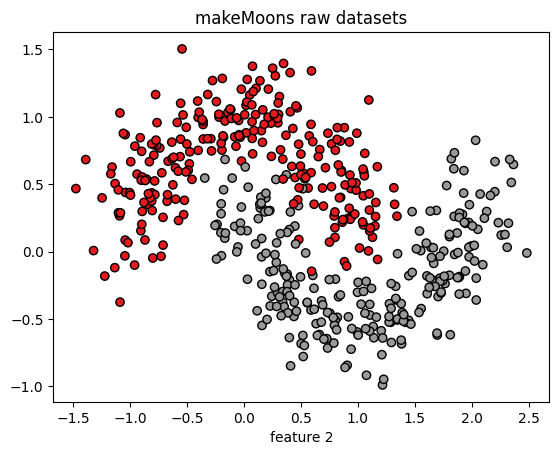

training accuracy: 0.983
test accuracy: 0.99
1250/1250 [==============================] - 0s 318us/step


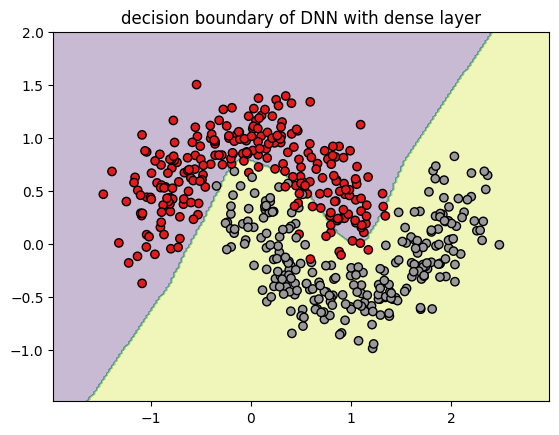

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection  import train_test_split
from sklearn.preprocessing  import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
x,y=make_moons(n_samples=500,noise=0.2,random_state=42)
print("shape of x:",x.shape)
print("shape of y:",y.shape)
print("first 5 sample of x:\n",x[:5])
print("first 5 sample of y:\n",y[:5])

plt.scatter(x[:,0],x[:,1],c=y,cmap=plt.cm.Set1,edgecolor="k")
plt.title("makeMoons raw datasets")
plt.xlabel("feature 1")
plt.xlabel("feature 2")
plt.show()

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.fit_transform(x_test)

model=Sequential([Dense(32,activation='relu',input_shape=(2,)),
                  Dense(16,activation='relu'),
                       Dense(8,activation='relu'),
                            Dense(1,activation='sigmoid')])

model.compile(optimizer=Adam(),loss='binary_crossentropy',metrics=['accuracy'])

history=model.fit(x_train,y_train,epochs=50,batch_size=32,verbose=0)

trainloss,trainacc=model.evaluate(x_train,y_train,verbose=0)
print("training accuracy:",round(trainacc,3))

testloss,testacc=model.evaluate(x_test,y_test,verbose=0)
print("test accuracy:",round(testacc,3))

xx,yy=np.meshgrid(np.linspace(x[:,0].min()-0.5,x[:,0].max()+0.5,200),
                 np.linspace(x[:,1].min()-0.5,x[:,1].max()+0.5,200))

z=model.predict(sc.transform(
        np.c_[xx.ravel(),yy.ravel()]))

z=(z>0.15).astype(int).reshape(xx.shape)

plt.contourf(xx,yy,z,alpha=0.3)

plt.scatter(x[:,0],x[:,1],c=y,cmap=plt.cm.Set1,edgecolor="k")

plt.title("decision boundary of DNN with dense layer")

plt.show()

shape of x: (500, 2)
shape of y: (500,)
first 5 sample of x:
 [[-5.73035386 -7.58328602]
 [ 1.94299219  1.91887482]
 [ 6.82968177  1.1648714 ]
 [-2.90130578  7.55077118]
 [ 5.84109276  1.56509431]]
first 5 sample of y:
 [2 1 1 0 1]


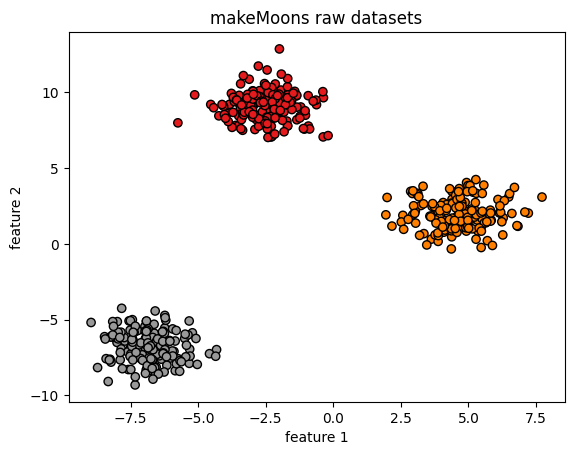

training accuracy: 1.0
test accuracy: 1.0
1250/1250 [==============================] - 0s 334us/step


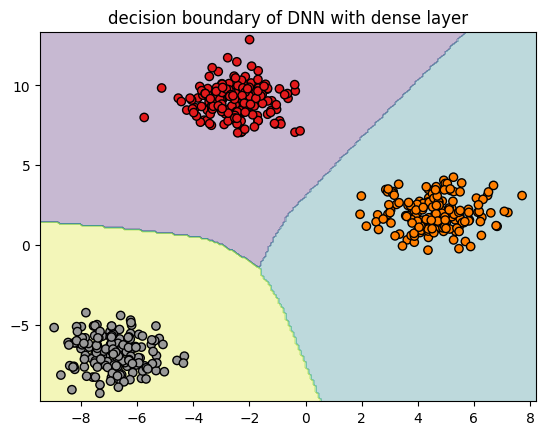

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection  import train_test_split
from sklearn.preprocessing  import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
x,y=make_blobs(n_samples=500,random_state=42)
print("shape of x:",x.shape)
print("shape of y:",y.shape)
print("first 5 sample of x:\n",x[:5])
print("first 5 sample of y:\n",y[:5])

plt.scatter(x[:,0],x[:,1],c=y,cmap=plt.cm.Set1,edgecolor="k")
plt.title("makeMoons raw datasets")
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.show()

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.fit_transform(x_test)

model=Sequential([Dense(32,activation='relu',input_shape=(2,)),
                  Dense(16,activation='relu'),
                       Dense(8,activation='relu'),
                            Dense(3,activation='softmax')])

model.compile(optimizer=Adam(),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

history=model.fit(x_train,y_train,epochs=50,batch_size=32,verbose=0)

trainloss,trainacc=model.evaluate(x_train,y_train,verbose=0)
print("training accuracy:",round(trainacc,3))

testloss,testacc=model.evaluate(x_test,y_test,verbose=0)
print("test accuracy:",round(testacc,3))

xx,yy=np.meshgrid(np.linspace(x[:,0].min()-0.5,x[:,0].max()+0.5,200),
                 np.linspace(x[:,1].min()-0.5,x[:,1].max()+0.5,200))

z=model.predict(sc.transform(
        np.c_[xx.ravel(),yy.ravel()]))

z=z.argmax(axis=1).reshape(xx.shape)

plt.contourf(xx,yy,z,alpha=0.3)

plt.scatter(x[:,0],x[:,1],c=y,cmap=plt.cm.Set1,edgecolor="k")

plt.title("decision boundary of DNN with dense layer")

plt.show()

shape of x: (500, 2)
shape of y: (500,)
first 5 sample of x:
 [[ 0.83049507 -0.48552934]
 [ 0.60500103  0.79622469]
 [ 0.99369162 -0.4999801 ]
 [-0.37538634  0.92686844]
 [ 0.25577103  0.96673739]]
first 5 sample of y:
 [1 0 1 0 0]


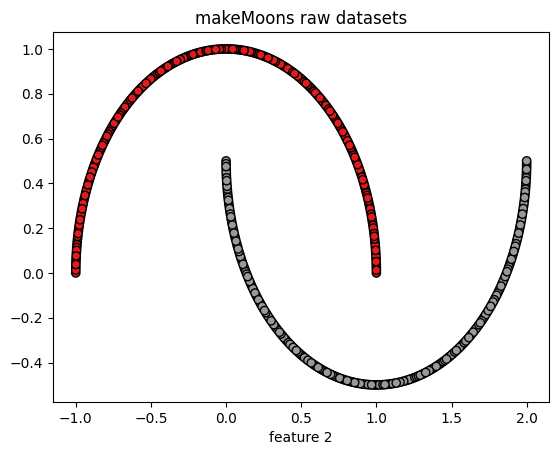

training accuracy: 1.0
test accuracy: 1.0
1250/1250 [==============================] - 0s 334us/step


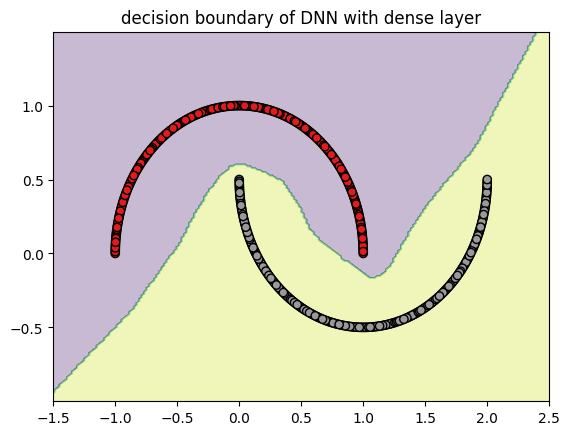

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection  import train_test_split
from sklearn.preprocessing  import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

x,y=make_moons(n_samples=500,noise=0,random_state=42)
print("shape of x:",x.shape)
print("shape of y:",y.shape)
print("first 5 sample of x:\n",x[:5])
print("first 5 sample of y:\n",y[:5])

plt.scatter(x[:,0],x[:,1],c=y,cmap=plt.cm.Set1,edgecolor="k")
plt.title("makeMoons raw datasets")
plt.xlabel("feature 1")
plt.xlabel("feature 2")
plt.show()

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.fit_transform(x_test)

model=Sequential([Dense(32,activation='relu',input_shape=(2,)),
                  Dense(16,activation='relu'),
                       Dense(8,activation='relu'),
                            Dense(1,activation='sigmoid')])

model.compile(optimizer=Adam(),loss='binary_crossentropy',metrics=['accuracy'])

history=model.fit(x_train,y_train,epochs=50,batch_size=32,verbose=0)

trainloss,trainacc=model.evaluate(x_train,y_train,verbose=0)
print("training accuracy:",round(trainacc,3))

testloss,testacc=model.evaluate(x_test,y_test,verbose=0)
print("test accuracy:",round(testacc,3))

xx,yy=np.meshgrid(np.linspace(x[:,0].min()-0.5,x[:,0].max()+0.5,200),
                 np.linspace(x[:,1].min()-0.5,x[:,1].max()+0.5,200))

z=model.predict(sc.transform(
        np.c_[xx.ravel(),yy.ravel()]))

z=(z>0.5).astype(int).reshape(xx.shape)

plt.contourf(xx,yy,z,alpha=0.3)

plt.scatter(x[:,0],x[:,1],c=y,cmap=plt.cm.Set1,edgecolor="k")

plt.title("decision boundary of DNN with dense layer")

plt.show()

# EXP3

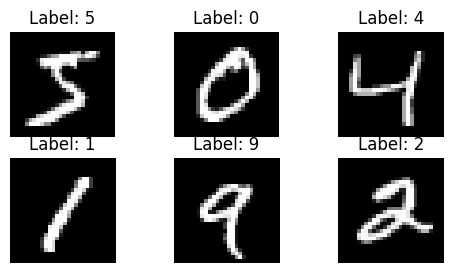

Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_8 (Conv2D)           (None, 26, 26, 8)         80        
                                                                 
 max_pooling2d_8 (MaxPooling  (None, 13, 13, 8)        0         
 2D)                                                             
                                                                 
 flatten_8 (Flatten)         (None, 1352)              0         
                                                                 
 dense_16 (Dense)            (None, 32)                43296     
                                                                 
 dense_17 (Dense)            (None, 10)                330       
                                                                 
Total params: 43,706
Trainable params: 43,706
Non-trainable params: 0
__________________________________________________

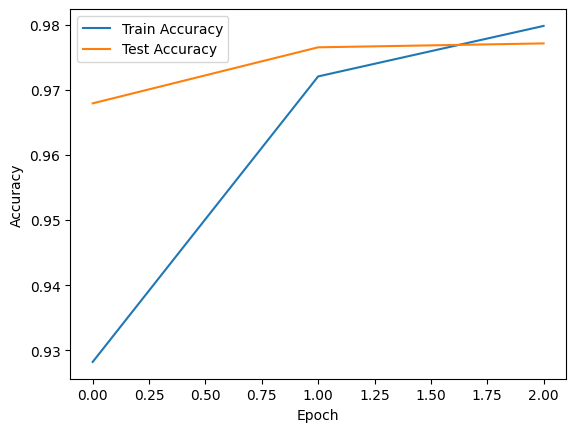

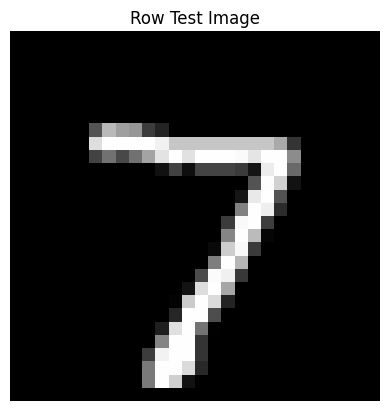

1/1 [==============================] - 0s 29ms/step
Model prediction: 7
True label: 7


In [13]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
(X_train, y_train),(X_test,y_test)=datasets.mnist.load_data()
plt.figure(figsize=(6,3))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(X_train[i],cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.show()
X_train=X_train/255.0
X_test=X_test/255.0
X_train=X_train[...,np.newaxis]
X_test=X_test[...,np.newaxis]
model=models.Sequential([layers.Conv2D(8,(3,3),activation='relu',input_shape=(28,28,1)),
                        layers.MaxPooling2D((2,2)),
                        layers.Flatten(),
                         layers.Dense(32,activation='relu'),
                         layers.Dense(10,activation='softmax')
])
model.summary()
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
history=model.fit(X_train,y_train,epochs=3,validation_data=(X_test,y_test))
plt.plot(history.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy'],label='Test Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()
test_img=X_test[0]
plt.imshow(test_img.reshape(28,28),cmap="gray")
plt.title("Row Test Image")
plt.axis("off")
plt.show()
pred=model.predict(test_img[np.newaxis,...])
print("Model prediction:",np.argmax(pred))
print("True label:",y_test[0])

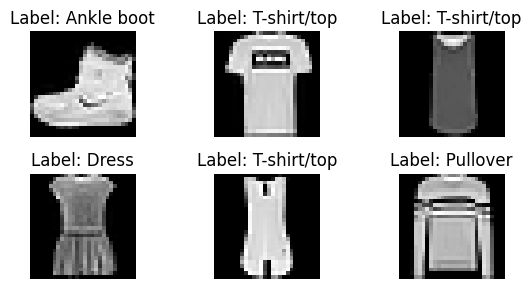

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_7 (Conv2D)           (None, 26, 26, 8)         80        
                                                                 
 max_pooling2d_7 (MaxPooling  (None, 13, 13, 8)        0         
 2D)                                                             
                                                                 
 flatten_7 (Flatten)         (None, 1352)              0         
                                                                 
 dense_14 (Dense)            (None, 35)                47355     
                                                                 
 dense_15 (Dense)            (None, 10)                360       
                                                                 
Total params: 47,795
Trainable params: 47,795
Non-trainable params: 0
__________________________________________________

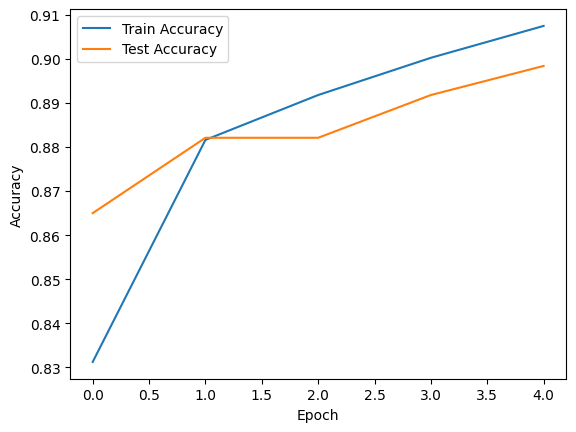

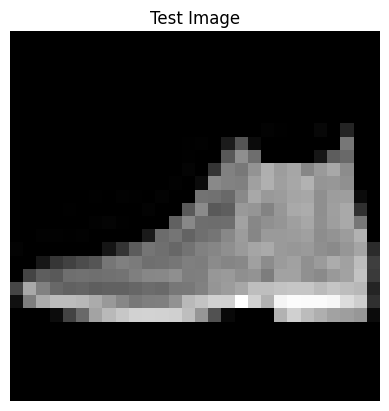

1/1 [==============================] - 0s 32ms/step
Model prediction: Ankle boot
True label: Ankle boot


In [12]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
(X_train, y_train), (X_test, y_test) = datasets.fashion_mnist.load_data()
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

plt.figure(figsize=(6, 3))

for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {class_names[y_train[i]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]


model = models.Sequential([
    layers.Conv2D(
        8,
        (3, 3),
        activation="relu",
        input_shape=(28, 28, 1)
    ),

    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(35, activation="relu"),

    layers.Dense(10, activation="softmax")
])

model.summary()

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_data=(X_test, y_test)
)


plt.plot(
    history.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Test Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


test_img = X_test[0]

plt.imshow(
    test_img.reshape(28, 28),
    cmap="gray"
)

plt.title("Test Image")
plt.axis("off")
plt.show()


pred = model.predict(test_img[np.newaxis, ...])

predicted_class = np.argmax(pred)

print("Model prediction:", class_names[predicted_class])
print("True label:", class_names[y_test[0]])

# EXP4

Epoch 1/5
235/235 [==============================] - 1s 3ms/step - loss: 0.0621 - val_loss: 0.0361
Epoch 2/5
235/235 [==============================] - 1s 3ms/step - loss: 0.0297 - val_loss: 0.0244
Epoch 3/5
235/235 [==============================] - 1s 3ms/step - loss: 0.0228 - val_loss: 0.0203
Epoch 4/5
235/235 [==============================] - 1s 3ms/step - loss: 0.0195 - val_loss: 0.0179
Epoch 5/5
313/313 [==============================] - 0s 520us/step


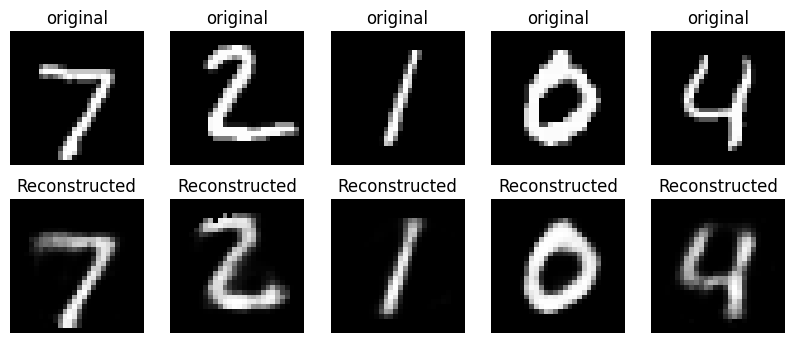

In [3]:
import tensorflow as tf
from tensorflow.keras import layers,models
import matplotlib.pyplot as plt
(x_train,_),(x_test,_)=tf.keras.datasets.mnist.load_data()
x_train=x_train.astype("float32")/255.0
x_test=x_test.astype("float32")/255.0
x_train=x_train.reshape(len(x_train),784)
x_test=x_test.reshape(len(x_test),784)


input_img=layers.Input(shape=(784,))
encoded=layers.Dense(128,activation='relu')(input_img)
encoded=layers.Dense(64,activation='relu')(encoded)
encoded=layers.Dense(42,activation='relu')(encoded)


decoded=layers.Dense(64,activation='relu')(encoded)
decoded=layers.Dense(128,activation='relu')(decoded)
decoded=layers.Dense(784,activation='sigmoid')(decoded)


autoencoder=models.Model(input_img,decoded)
autoencoder.compile(optimizer='adam',loss='mse')
autoencoder.fit(x_train,x_train,
               epochs=5,batch_size=256,
               shuffle=True,
               validation_data=(x_test,x_test))
decoded_img=autoencoder.predict(x_test)
n=5

plt.figure(figsize=(10,4))
for i in range(n):
    ax=plt.subplot(2,n,i+1)
    plt.imshow(x_test[i].reshape(28,28),cmap='gray')
    plt.title("original")
    plt.axis("OFF")
    ax=plt.subplot(2,n,i+1+n)
    plt.imshow(decoded_img[i].reshape(28,28),cmap='gray')
    plt.title("Reconstructed")
    plt.axis("OFF")
plt.show()

Epoch 1/5
235/235 [==============================] - 1s 4ms/step - loss: 0.0584 - val_loss: 0.0316
Epoch 2/5
235/235 [==============================] - 1s 4ms/step - loss: 0.0289 - val_loss: 0.0225
Epoch 3/5
235/235 [==============================] - 1s 3ms/step - loss: 0.0242 - val_loss: 0.0173
Epoch 4/5
235/235 [==============================] - 1s 3ms/step - loss: 0.0218 - val_loss: 0.0150
Epoch 5/5
313/313 [==============================] - 0s 546us/step


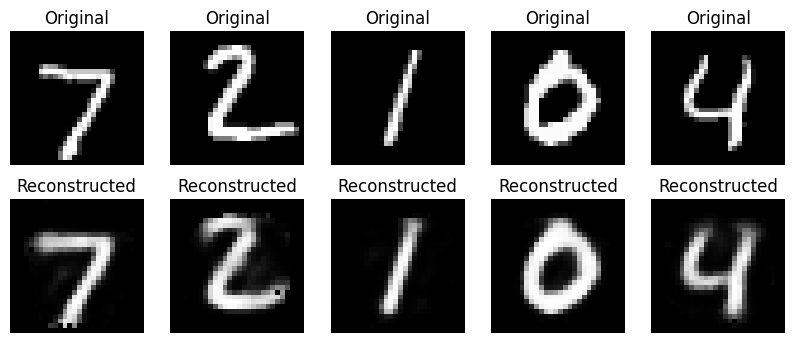

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

input_img = layers.Input(shape=(28, 28))

noisy_input = layers.GaussianNoise(0.5)(input_img)

flattened = layers.Flatten()(noisy_input)

encoded = layers.Dense(128, activation="relu")(flattened)
encoded = layers.Dense(64, activation="relu")(encoded)

decoded = layers.Dense(128, activation="relu")(encoded)
decoded = layers.Dense(784, activation="sigmoid")(decoded)

output_img = layers.Reshape((28, 28))(decoded)

autoencoder = models.Model(input_img, output_img)

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder.fit(
    x_train,
    x_train,
    epochs=5,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

decoded_img = autoencoder.predict(x_test)

n = 5

plt.figure(figsize=(10, 4))

for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title("Original")
    plt.axis("off")

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_img[i], cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

plt.show()


# EXP5

In [19]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,Dense,Flatten
documents=[
    "I love deep learning",
    "Deep learning is amazing",
    "I enjoy machine learning",
    "Natural language processing is fun",
    "I dislike bugs in code",
    "Debugging code can be hard",
    "I hate syntax error",
    "Errors make me frustrated"
]
labels=[1,1,1,1,0,0,0,0]
tokenizer=Tokenizer(num_words=50)
tokenizer.fit_on_texts(documents)
sequences=tokenizer.texts_to_sequences(documents)
print("Word Index:",tokenizer.word_index)
print("Sequences:", sequences)
X=pad_sequences(sequences, maxlen=6)
y=np.array(labels)
print("Padded Sequences:\n",X)
model=Sequential()
model.add(Embedding(input_dim=50,output_dim=8,input_length=6))
model.add(Flatten())
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model.fit(X,y,epochs=20,verbose=1) 
embeddings=model.layers[0].get_weights()[0]
print("\nWord Embeddings Shape:",embeddings.shape)
test_text=["I love coding"]
test_seq=tokenizer.texts_to_sequences(test_text)
test_pad=pad_sequences(test_seq,maxlen=6)
prediction=model.predict(test_pad)
print("Prediction:",prediction)
print("Class:","Positive" if prediction>0.5 else "Negative")

Word Index: {'i': 1, 'learning': 2, 'deep': 3, 'is': 4, 'code': 5, 'love': 6, 'amazing': 7, 'enjoy': 8, 'machine': 9, 'natural': 10, 'language': 11, 'processing': 12, 'fun': 13, 'dislike': 14, 'bugs': 15, 'in': 16, 'debugging': 17, 'can': 18, 'be': 19, 'hard': 20, 'hate': 21, 'syntax': 22, 'error': 23, 'errors': 24, 'make': 25, 'me': 26, 'frustrated': 27}
Sequences: [[1, 6, 3, 2], [3, 2, 4, 7], [1, 8, 9, 2], [10, 11, 12, 4, 13], [1, 14, 15, 16, 5], [17, 5, 18, 19, 20], [1, 21, 22, 23], [24, 25, 26, 27]]
Padded Sequences:
 [[ 0  0  1  6  3  2]
 [ 0  0  3  2  4  7]
 [ 0  0  1  8  9  2]
 [ 0 10 11 12  4 13]
 [ 0  1 14 15 16  5]
 [ 0 17  5 18 19 20]
 [ 0  0  1 21 22 23]
 [ 0  0 24 25 26 27]]
Epoch 1/20
1/1 [==============================] - 0s 277ms/step - loss: 0.6904 - accuracy: 0.5000
Epoch 2/20
1/1 [==============================] - 0s 3ms/step - loss: 0.6868 - accuracy: 0.5000
Epoch 3/20
1/1 [==============================] - 0s 4ms/step - loss: 0.6832 - accuracy: 0.5000
Epoch 4/20
1/

In [18]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,Dense,Flatten
documents=[
    "I love deep learning",
    "Deep learning is amazing",
    "I enjoy machine learning",
    "Natural language processing is fun",
    "I dislike bugs in code",
    "Debugging code can be hard",
    "I hate syntax error",
    "Errors make me frustrated"
]
labels=[1,1,1,1,0,0,0,0]
tokenizer=Tokenizer(num_words=50)
tokenizer.fit_on_texts(documents)
sequences=tokenizer.texts_to_sequences(documents)
print("Word Index:",tokenizer.word_index)
print("Sequences:", sequences)
X=pad_sequences(sequences, maxlen=6)
y=np.array(labels)
print("Padded Sequences:\n",X)
model=Sequential()
model.add(Embedding(input_dim=50,output_dim=8,input_length=6))
model.add(Flatten())
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model.fit(X,y,epochs=20,verbose=1) 
embeddings=model.layers[0].get_weights()[0]
print("\nWord Embeddings Shape:",embeddings.shape)
test_text = [
    "I love coding",
    "I hate bugs",
    "Learning is amazing",
    "Syntax errors are frustrating",
    "I enjoy deep learning"
]

test_seq = tokenizer.texts_to_sequences(test_text)
test_pad = pad_sequences(test_seq, maxlen=6)

predictions = model.predict(test_pad)

for text, prediction in zip(test_text, predictions):
    sentiment = "Positive" if prediction[0] > 0.5 else "Negative"
    print(text, "->", prediction[0], "->", sentiment)


Word Index: {'i': 1, 'learning': 2, 'deep': 3, 'is': 4, 'code': 5, 'love': 6, 'amazing': 7, 'enjoy': 8, 'machine': 9, 'natural': 10, 'language': 11, 'processing': 12, 'fun': 13, 'dislike': 14, 'bugs': 15, 'in': 16, 'debugging': 17, 'can': 18, 'be': 19, 'hard': 20, 'hate': 21, 'syntax': 22, 'error': 23, 'errors': 24, 'make': 25, 'me': 26, 'frustrated': 27}
Sequences: [[1, 6, 3, 2], [3, 2, 4, 7], [1, 8, 9, 2], [10, 11, 12, 4, 13], [1, 14, 15, 16, 5], [17, 5, 18, 19, 20], [1, 21, 22, 23], [24, 25, 26, 27]]
Padded Sequences:
 [[ 0  0  1  6  3  2]
 [ 0  0  3  2  4  7]
 [ 0  0  1  8  9  2]
 [ 0 10 11 12  4 13]
 [ 0  1 14 15 16  5]
 [ 0 17  5 18 19 20]
 [ 0  0  1 21 22 23]
 [ 0  0 24 25 26 27]]
Epoch 1/20
1/1 [==============================] - 0s 433ms/step - loss: 0.7149 - accuracy: 0.1250
Epoch 2/20
1/1 [==============================] - 0s 3ms/step - loss: 0.7115 - accuracy: 0.1250
Epoch 3/20
1/1 [==============================] - 0s 3ms/step - loss: 0.7084 - accuracy: 0.2500
Epoch 4/20
1/